# LLM Evaluation

**Evaluates** intent classification and attribute extraction prompts against a labelled test dataset.

Metrics produced:
- Per-class Precision / Recall / F1 + macro & weighted averages
- Confusion matrix (heatmap)
- Per-field extraction accuracy
- Hallucination & invalid-value detection
- Latency (mean, p50, p95) and estimated API cost

In [32]:
import json
import sys
import time
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Optional

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import seaborn as sns

sys.path.insert(0, "main")          

import LLM_agent as _agent

VALID_INTENTS = {"RECOMMEND", "ALTERNATIVE", "FEEDBACK_POS", "FEEDBACK_NEG", "SMALLTALK", "OTHER"}

VALID_ATTRIBUTES = {
    "UserAge":        {"young", "adult", "senior"},
    "UserGender":     {"male", "female"},
    "HouseholdType":  {"single", "couple", "family"},
    "TimeOfDay":      {"morning", "afternoon", "night"},
    "DayType":        {"weekday", "weekend"},
    "ProgramType":    {"movie", "series", "news", "documentary", "entertainment"},
    "ProgramGenre":   {"comedy", "drama", "horror", "romance", "news", "documentary",
                       "entertainment", "action", "thriller", "sci-fi", "fantasy"},
    "ProgramDuration":{"short", "medium", "long"},
}

print("✅ Setup complete")

✅ Setup complete


### Test Datasets

In [33]:
# Each tuple: (message, expected_intent, difficulty, notes)
INTENT_TEST_CASES = [
    # ── ALTERNATIVE: el usuario pide/prefiere algo diferente ─────────────────
    # (no expresa dislike directo, sino que quiere una alternativa)
    ("Nada de terror",                      "ALTERNATIVE", "easy",   "genre rejection"),
    ("No quiero ver comedias",              "ALTERNATIVE", "easy",   "genre rejection"),
    ("Algo que no sea romántico",           "ALTERNATIVE", "easy",   "genre rejection"),
    ("Prefiero otro género",                "ALTERNATIVE", "medium", "vague genre alternative"),
    ("Sin drama por favor",                 "ALTERNATIVE", "easy",   "genre rejection"),
    ("Nada de ciencia ficción",             "ALTERNATIVE", "easy",   "genre rejection"),
    ("Dame otra opción",                    "ALTERNATIVE", "easy",   "simple alternative"),
    ("Otra cosa",                           "ALTERNATIVE", "easy",   "simple alternative"),
    ("Algo diferente",                      "ALTERNATIVE", "easy",   "simple alternative"),
    ("¿Hay algo más?",                      "ALTERNATIVE", "medium", "implicit alternative"),
    ("No es lo que busco",                  "ALTERNATIVE", "hard",   "implicit rejection"),
    ("Prefiero ver otra cosa",              "ALTERNATIVE", "medium", "explicit preference for alternative"),
    ("Prefiero algo diferente",             "ALTERNATIVE", "easy",   "explicit preference for alternative"),
    ("¿No tienes otra cosa?",               "ALTERNATIVE", "medium", "implicit request for alternative"),
    ("Quiero algo más corto",               "ALTERNATIVE", "hard",   "attribute-based alternative"),
    ("No quiero ver nada de eso",           "ALTERNATIVE", "hard",   "vague broad rejection"),
    # ── FEEDBACK_NEG: el usuario expresa que no le gusta algo ────────────────
    # (dislike directo — de la recomendación o del género/tipo)
    ("No me gusta el drama",                "FEEDBACK_NEG", "easy",  "genre dislike"),
    ("No me gustan las comedias",           "FEEDBACK_NEG", "medium","genre dislike plural"),
    ("No me gusta ese tipo de películas",   "FEEDBACK_NEG", "medium","type dislike"),
    ("Esa no me gusta",                     "FEEDBACK_NEG", "easy",  "specific recommendation rejection"),
    ("Ya la vi",                            "FEEDBACK_NEG", "easy",  "already seen"),
    ("No me convence esa película",         "FEEDBACK_NEG", "easy",  "specific rejection"),
    ("Esa es muy larga",                    "FEEDBACK_NEG", "medium","attribute-based rejection"),
    ("No, esa no",                          "FEEDBACK_NEG", "medium","short negative"),
    ("La he visto ya",                      "FEEDBACK_NEG", "easy",  "already seen variant"),
    ("Esa película no me llama la atención","FEEDBACK_NEG", "medium","paraphrase"),
    ("Me aburre un poco",                   "FEEDBACK_NEG", "hard",  "implicit mild rejection"),
    # ── FEEDBACK_POS: el usuario expresa que le gusta algo ───────────────────
    ("Me gusta",                            "FEEDBACK_POS", "easy",  "simple positive"),
    ("Perfecto",                            "FEEDBACK_POS", "easy",  "simple positive"),
    ("La veo",                              "FEEDBACK_POS", "easy",  "commitment"),
    ("De acuerdo",                          "FEEDBACK_POS", "easy",  "agreement"),
    ("Buena idea",                          "FEEDBACK_POS", "medium","implicit positive"),
    ("Sí, me apetece",                      "FEEDBACK_POS", "medium","positive with desire"),
    ("Esa me parece bien",                  "FEEDBACK_POS", "medium","acceptance"),
    ("Me gusta ese tipo de series",         "FEEDBACK_POS", "medium","positive about type/genre"),
    ("Sí, la veo",                          "FEEDBACK_POS", "easy",  "explicit acceptance"),
    # ── RECOMMEND ───────────────────────────────────────────────────────────
    ("Quiero ver una película",             "RECOMMEND", "easy",    "type request"),
    ("Qué puedo ver",                       "RECOMMEND", "easy",    "open recommendation"),
    ("Recomiéndame algo",                   "RECOMMEND", "easy",    "explicit request"),
    ("Quiero ver una comedia",              "RECOMMEND", "easy",    "genre + type"),
    ("Ponme algo de acción",                "RECOMMEND", "easy",    "genre request"),
    ("¿Qué hay bueno hoy?",                 "RECOMMEND", "medium",  "temporal rec request"),
    ("Busco una serie entretenida",         "RECOMMEND", "medium",  "series request"),
    # ── SMALLTALK ───────────────────────────────────────────────────────────
    ("Hola",                                "SMALLTALK", "easy",    "greeting"),
    ("Gracias",                             "SMALLTALK", "easy",    "thanks"),
    ("Adiós",                               "SMALLTALK", "easy",    "farewell"),
    ("¿Cómo estás?",                        "SMALLTALK", "medium",  "social question"),
    ("Muy bien",                            "SMALLTALK", "hard",    "ambiguous positive"),
]

# Each tuple: (message, expected_attrs_dict)
EXTRACTION_TEST_CASES = [
    ("Quiero ver una comedia de 90 minutos",
        {"ProgramType": "movie", "ProgramGenre": "comedy", "ProgramDuration": "long"}),
    ("Soy un chico de 32 años",
        {"UserAge": "young", "UserGender": "male"}),
    ("Somos una familia y queremos ver una serie esta tarde",
        {"HouseholdType": "family", "ProgramType": "series", "TimeOfDay": "afternoon"}),
    ("Quiero ver algo de terror por la noche",
        {"ProgramGenre": "horror", "TimeOfDay": "night"}),
    ("Soy una señora mayor de 70 años y vivo sola",
        {"UserAge": "senior", "UserGender": "female", "HouseholdType": "single"}),
    ("Un documental corto para el fin de semana",
        {"ProgramType": "documentary", "ProgramDuration": "short", "DayType": "weekend"}),
    ("Algo de acción, somos una pareja",
        {"ProgramGenre": "action", "HouseholdType": "couple"}),
    ("Quiero ver las noticias",
        {"ProgramType": "news", "ProgramGenre": "news"}),
    ("Una película de ciencia ficción larga",
        {"ProgramType": "movie", "ProgramGenre": "sci-fi", "ProgramDuration": "long"}),
    ("Hola, ¿qué hay?",
        {}),
    ("Algo entretenido para esta noche entre semana",
        {"ProgramGenre": "entertainment", "TimeOfDay": "night", "DayType": "weekday"}),
    ("Tengo 45 años y vivo en pareja",
        {"UserAge": "adult", "HouseholdType": "couple"}),
]

print(f"Intent test cases:     {len(INTENT_TEST_CASES)}")
print(f"Extraction test cases: {len(EXTRACTION_TEST_CASES)}")

Intent test cases:     48
Extraction test cases: 12


#### Data Structures and Metric Helpers

In [34]:
@dataclass
class IntentResult:
    message:    str
    expected:   str
    predicted:  str
    correct:    bool
    difficulty: str
    notes:      str
    latency_ms: float
    tokens_in:  int
    tokens_out: int


@dataclass
class ExtractionResult:
    message:       str
    expected:      dict
    predicted:     dict
    field_hits:    int
    field_misses:  int
    hallucinations:int
    invalid_values:int
    latency_ms:    float
    tokens_in:     int
    tokens_out:    int


# ── Metric helpers ────────────────────────────────────────────────────────────

def confusion_matrix_data(results, classes):
    idx = {c: i for i, c in enumerate(classes)}
    n   = len(classes)
    mat = [[0] * n for _ in range(n)]
    for r in results:
        if r.expected in idx and r.predicted in idx:
            mat[idx[r.expected]][idx[r.predicted]] += 1
        elif r.expected in idx:
            mat[idx[r.expected]][idx.get("OTHER", 0)] += 1
    return mat


def per_class_metrics(results, classes):
    tp = defaultdict(int); fp = defaultdict(int); fn = defaultdict(int)
    for r in results:
        if r.predicted == r.expected:
            tp[r.expected] += 1
        else:
            fp[r.predicted] += 1
            fn[r.expected]  += 1
    metrics = {}
    for c in classes:
        p  = tp[c] / (tp[c] + fp[c]) if (tp[c] + fp[c]) > 0 else 0.0
        r_ = tp[c] / (tp[c] + fn[c]) if (tp[c] + fn[c]) > 0 else 0.0
        f1 = 2 * p * r_ / (p + r_) if (p + r_) > 0 else 0.0
        metrics[c] = {"precision": p, "recall": r_, "f1": f1, "support": tp[c] + fn[c]}
    return metrics


def macro_avg(per_class):
    keys = list(per_class)
    return {k: sum(per_class[c][k] for c in keys) / len(keys) for k in ("precision","recall","f1")}


def weighted_avg(per_class):
    total = sum(per_class[k]["support"] for k in per_class)
    if not total:
        return {"precision": 0, "recall": 0, "f1": 0}
    return {k: sum(per_class[c][k] * per_class[c]["support"] for c in per_class) / total
            for k in ("precision","recall","f1")}


def latency_stats(values):
    s = sorted(values); n = len(s)
    pct = lambda p: s[int(p/100*(n-1))] if n else 0
    return {"mean_ms": sum(s)/n if n else 0,
            "p50_ms": pct(50), "p95_ms": pct(95), "max_ms": s[-1] if s else 0}

print("✅ Helpers defined")

✅ Helpers defined


#### Intent Classification Tests

In [35]:
def run_intent_tests(verbose=True):
    results = []
    for message, expected, difficulty, notes in INTENT_TEST_CASES:
        t0 = time.perf_counter()
        try:
            resp = _agent.client.chat.completions.create(
                model="gpt-4o",
                messages=[
                    {"role": "system", "content": _agent.INTENT_PROMPT},
                    {"role": "user",   "content": message},
                ],
                temperature=0,
            )
            latency_ms = (time.perf_counter() - t0) * 1000
            content    = _agent.clean_json_response(resp.choices[0].message.content)
            try:
                predicted = json.loads(content).get("intent", "OTHER")
            except json.JSONDecodeError:
                predicted = "OTHER"
            tokens_in  = resp.usage.prompt_tokens
            tokens_out = resp.usage.completion_tokens
        except Exception as e:
            latency_ms = (time.perf_counter() - t0) * 1000
            predicted  = "OTHER"
            tokens_in = tokens_out = 0
            print(f"  ❌ API error: {e}")

        correct = predicted == expected
        results.append(IntentResult(
            message=message, expected=expected, predicted=predicted,
            correct=correct, difficulty=difficulty, notes=notes,
            latency_ms=latency_ms, tokens_in=tokens_in, tokens_out=tokens_out,
        ))
        if verbose:
            icon = "✅" if correct else "❌"
            diff_tag = f"[{difficulty}]"
            print(f"  {icon} {diff_tag:<8} {message:<44} | expected: {expected:<15} | got: {predicted:<15} | {latency_ms:5.0f}ms")

    classes   = sorted(VALID_INTENTS)
    pc        = per_class_metrics(results, classes)
    correct_n = sum(1 for r in results if r.correct)
    accuracy  = correct_n / len(results)
    lat       = latency_stats([r.latency_ms for r in results])
    total_in  = sum(r.tokens_in  for r in results)
    total_out = sum(r.tokens_out for r in results)

    diff_groups = defaultdict(list)
    for r in results:
        diff_groups[r.difficulty].append(r.correct)
    diff_acc = {d: sum(v)/len(v) for d, v in diff_groups.items()}

    summary = {
        "accuracy": accuracy, "correct": correct_n, "total": len(results),
        "per_class": pc, "macro_avg": macro_avg(pc), "weighted_avg": weighted_avg(pc),
        "by_difficulty": diff_acc, "latency": lat,
        "tokens": {"input": total_in, "output": total_out},
        "confusion_matrix": {"classes": classes, "matrix": confusion_matrix_data(results, classes)},
    }
    return results, summary

intent_results, intent_summary = run_intent_tests(verbose=True)
print(f"\n✅ Intent tests complete — Accuracy: {intent_summary['accuracy']:.1%}")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  ✅ [easy]   Nada de terror                               | expected: ALTERNATIVE     | got: ALTERNATIVE     |   856ms


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  ✅ [easy]   No quiero ver comedias                       | expected: ALTERNATIVE     | got: ALTERNATIVE     |   926ms


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

  ✅ [easy]   Adiós                                        | expected: SMALLTALK       | got: SMALLTALK       |   920ms


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  ✅ [medium] ¿Cómo estás?                                 | expected: SMALLTALK       | got: SMALLTALK       |   832ms


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  ❌ [hard]   Muy bien                                     | expected: SMALLTALK       | got: FEEDBACK_POS    |   599ms

✅ Intent tests complete — Accuracy: 97.9%


#### Attribute Extraction Tests

In [36]:
def run_extraction_tests(verbose=True):
    results = []
    for message, expected_attrs in EXTRACTION_TEST_CASES:
        t0 = time.perf_counter()
        try:
            resp = _agent.client.chat.completions.create(
                model="gpt-4o",
                messages=[
                    {"role": "system", "content": _agent.EXTRACTION_PROMPT},
                    {"role": "user",   "content": message},
                ],
                temperature=0,
            )
            latency_ms = (time.perf_counter() - t0) * 1000
            content    = _agent.clean_json_response(resp.choices[0].message.content)
            try:
                predicted_raw = json.loads(content)
            except json.JSONDecodeError:
                predicted_raw = {}
            tokens_in  = resp.usage.prompt_tokens
            tokens_out = resp.usage.completion_tokens
        except Exception as e:
            latency_ms = (time.perf_counter() - t0) * 1000
            predicted_raw = {}
            tokens_in = tokens_out = 0
            print(f"  ❌ API error: {e}")

        predicted = {k: (None if v in (None, "", "null", "NULL") else v)
                     for k, v in predicted_raw.items()}

        hits = misses = hallucinations = invalid_values = 0
        field_details = []

        for key in VALID_ATTRIBUTES:
            exp_val  = expected_attrs.get(key)
            pred_val = predicted.get(key)
            if exp_val is None:
                if pred_val is not None:
                    hallucinations += 1
                    field_details.append(("HALLUCINATION", key, None, pred_val))
            else:
                if pred_val == exp_val:
                    hits += 1
                    field_details.append(("OK", key, exp_val, pred_val))
                elif pred_val is None:
                    misses += 1
                    field_details.append(("MISS", key, exp_val, pred_val))
                elif pred_val not in VALID_ATTRIBUTES.get(key, set()):
                    invalid_values += 1; misses += 1
                    field_details.append(("INVALID", key, exp_val, pred_val))
                else:
                    misses += 1
                    field_details.append(("WRONG", key, exp_val, pred_val))

        results.append(ExtractionResult(
            message=message, expected=expected_attrs, predicted=predicted,
            field_hits=hits, field_misses=misses,
            hallucinations=hallucinations, invalid_values=invalid_values,
            latency_ms=latency_ms, tokens_in=tokens_in, tokens_out=tokens_out,
        ))

        if verbose:
            ok = misses == 0 and hallucinations == 0
            icon = "✅" if ok else "❌"
            exp_n = len(expected_attrs)
            print(f"\n  {icon} \"{message}\"")
            print(f"     hits={hits}/{exp_n}  misses={misses}  hallucinations={hallucinations}  invalid={invalid_values}  {latency_ms:.0f}ms")
            for tag, key, exp_v, pred_v in field_details:
                if tag == "OK":
                    print(f"       ✔ {key}: '{pred_v}'")
                elif tag == "HALLUCINATION":
                    print(f"       🔴 HALLUCINATION {key}: expected null → got '{pred_v}'")
                elif tag == "MISS":
                    print(f"       🟡 MISS {key}: expected '{exp_v}' → got null")
                elif tag == "WRONG":
                    print(f"       🟠 WRONG {key}: expected '{exp_v}' → got '{pred_v}'")
                elif tag == "INVALID":
                    print(f"       🔴 INVALID {key}: expected '{exp_v}' → got '{pred_v}' (not in allowed set)")

    total_expected = sum(len(r.expected) for r in results)
    total_hits     = sum(r.field_hits for r in results)
    total_hallucs  = sum(r.hallucinations for r in results)
    total_invalid  = sum(r.invalid_values for r in results)
    perfect_cases  = sum(1 for r in results if r.field_misses == 0 and r.hallucinations == 0)
    lat            = latency_stats([r.latency_ms for r in results])
    total_in       = sum(r.tokens_in  for r in results)
    total_out      = sum(r.tokens_out for r in results)

    field_hits_map = defaultdict(list)
    for r in results:
        for key in VALID_ATTRIBUTES:
            exp_val  = r.expected.get(key)
            pred_val = r.predicted.get(key)
            if exp_val is None:
                field_hits_map[key].append(pred_val is None)
            else:
                field_hits_map[key].append(pred_val == exp_val)
    per_field_accuracy = {k: sum(v)/len(v) for k, v in field_hits_map.items()}

    summary = {
        "perfect_cases": perfect_cases, "total_cases": len(results),
        "perfect_rate": perfect_cases / len(results),
        "field_hit_rate": total_hits / total_expected if total_expected else 0,
        "total_hallucinations": total_hallucs,
        "total_invalid_values": total_invalid,
        "per_field_accuracy": per_field_accuracy,
        "latency": lat,
        "tokens": {"input": total_in, "output": total_out},
    }
    return results, summary

extraction_results, extraction_summary = run_extraction_tests(verbose=True)
print(f"\n✅ Extraction tests complete — Perfect cases: {extraction_summary['perfect_rate']:.1%}")

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



  ✅ "Quiero ver una comedia de 90 minutos"
     hits=3/3  misses=0  hallucinations=0  invalid=0  1077ms
       ✔ ProgramType: 'movie'
       ✔ ProgramGenre: 'comedy'
       ✔ ProgramDuration: 'long'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



  ✅ "Soy un chico de 32 años"
     hits=2/2  misses=0  hallucinations=0  invalid=0  891ms
       ✔ UserAge: 'young'
       ✔ UserGender: 'male'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...


  ✅ "Hola, ¿qué hay?"
     hits=0/0  misses=0  hallucinations=0  invalid=0  1055ms


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



  ❌ "Algo entretenido para esta noche entre semana"
     hits=3/3  misses=0  hallucinations=1  invalid=0  992ms
       ✔ TimeOfDay: 'night'
       ✔ DayType: 'weekday'
       🔴 HALLUCINATION ProgramType: expected null → got 'entertainment'
       ✔ ProgramGenre: 'entertainment'


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



  ✅ "Tengo 45 años y vivo en pareja"
     hits=2/2  misses=0  hallucinations=0  invalid=0  1025ms
       ✔ UserAge: 'adult'
       ✔ HouseholdType: 'couple'

✅ Extraction tests complete — Perfect cases: 83.3%


#### Intent Classification Results

In [37]:
# ── Per-class metrics table ───────────────────────────────────────────────────
pc = intent_summary["per_class"]
df_intent = pd.DataFrame([
    {"Class": c, "Precision": m["precision"], "Recall": m["recall"], "F1": m["f1"], "Support": m["support"]}
    for c, m in sorted(pc.items())
])

macro   = intent_summary["macro_avg"]
weighted_= intent_summary["weighted_avg"]
df_avgs  = pd.DataFrame([
    {"Class": "macro avg",    "Precision": macro["precision"],    "Recall": macro["recall"],    "F1": macro["f1"],    "Support": ""},
    {"Class": "weighted avg", "Precision": weighted_["precision"],"Recall": weighted_["recall"],"F1": weighted_["f1"],"Support": ""},
])
df_all = pd.concat([df_intent, df_avgs], ignore_index=True)


styled = (df_all.style
    .format({"Precision": "{:.2f}", "Recall": "{:.2f}", "F1": "{:.2f}"}, na_rep="")
    .set_caption(f"Overall Accuracy: {intent_summary['accuracy']:.1%}  "
                 f"({intent_summary['correct']}/{intent_summary['total']} correct)"))
display(styled)

,Class,Precision,Recall,F1,Support
0,ALTERNATIVE,1.00,1.00,1.00,16
1,FEEDBACK_NEG,1.00,1.00,1.00,11
2,FEEDBACK_POS,0.90,1.00,0.95,9
3,OTHER,0.00,0.00,0.00,0
4,RECOMMEND,1.00,1.00,1.00,7
5,SMALLTALK,1.00,0.80,0.89,5
6,macro avg,0.82,0.80,0.81,
7,weighted avg,0.98,0.98,0.98,


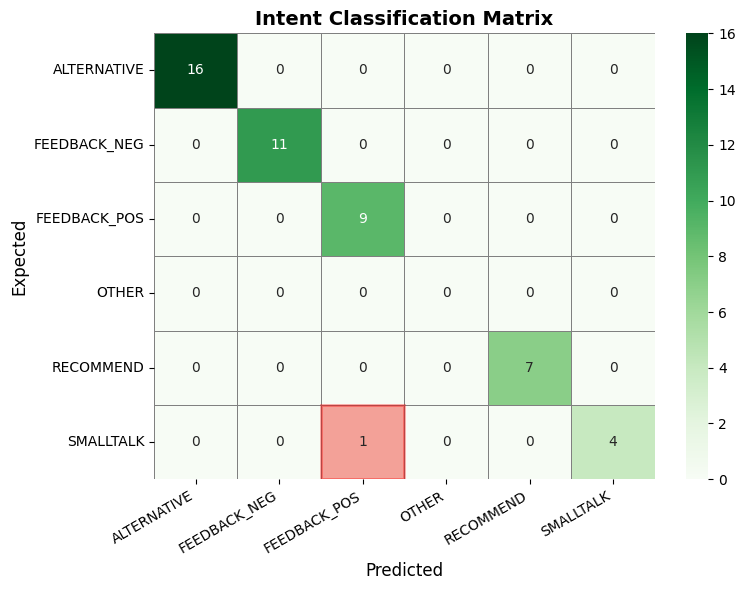

In [38]:
# ── Confusion matrix heatmap ─────────────────────────────────────────────────
import numpy as np

cm   = intent_summary["confusion_matrix"]
mat  = cm["matrix"]
cls  = cm["classes"]
mat_arr = np.array(mat)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(mat_arr, annot=True, fmt="d", cmap="Greens",
            xticklabels=cls, yticklabels=cls,
            linewidths=0.5, linecolor="grey", ax=ax)

# Highlight off-diagonal non-zero cells in red
for i in range(len(cls)):
    for j in range(len(cls)):
        if i != j and mat_arr[i, j] > 0:
            ax.add_patch(plt.Rectangle((j, i), 1, 1,
                fill=True, facecolor="red", alpha=0.35,
                edgecolor="red", linewidth=2))

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Expected",  fontsize=12)
ax.set_title("Intent Classification Matrix", fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

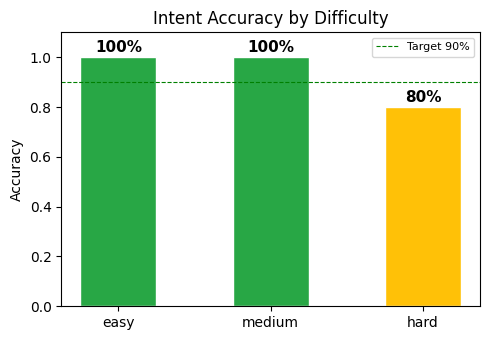

In [39]:
# ── Accuracy by difficulty ───────────────────────────────────────────────────
diff_data = intent_summary["by_difficulty"]
diff_order = ["easy", "medium", "hard"]
diff_vals  = [diff_data.get(d, 0) for d in diff_order]

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(diff_order, diff_vals,
              color=["#28a745" if v >= 0.90 else "#ffc107" if v >= 0.70 else "#dc3545"
                     for v in diff_vals],
              edgecolor="white", width=0.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy")
ax.set_title("Intent Accuracy by Difficulty")
ax.axhline(0.9, color="green", linestyle="--", linewidth=0.8, label="Target 90%")
for bar, val in zip(bars, diff_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.0%}", ha="center", fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


#### Attribute Extraction Results

In [40]:
# ── Summary KPIs ─────────────────────────────────────────────────────────────
es = extraction_summary
print(f"  Perfect cases  : {es['perfect_cases']}/{es['total_cases']}  ({es['perfect_rate']:.1%})")
print(f"  Field hit rate : {es['field_hit_rate']:.1%}")
print(f"  Hallucinations : {es['total_hallucinations']}")
print(f"  Invalid values : {es['total_invalid_values']}")


  Perfect cases  : 10/12  (83.3%)
  Field hit rate : 100.0%
  Hallucinations : 2
  Invalid values : 0


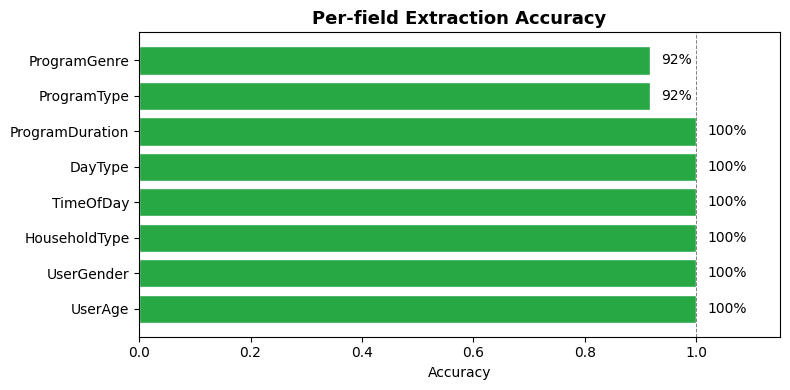

In [41]:
# ── Per-field accuracy bar chart ─────────────────────────────────────────────
pfa   = extraction_summary["per_field_accuracy"]
fields = sorted(pfa, key=pfa.get, reverse=True)
vals   = [pfa[f] for f in fields]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(fields, vals,
               color=["#28a745" if v >= 0.9 else "#ffc107" if v >= 0.7 else "#dc3545"
                      for v in vals],
               edgecolor="white")
ax.set_xlim(0, 1.15)
ax.set_xlabel("Accuracy")
ax.set_title("Per-field Extraction Accuracy", fontsize=13, fontweight="bold")
ax.axvline(1.0, color="grey", linestyle="--", linewidth=0.7)
for bar, val in zip(bars, vals):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.0%}", va="center", fontsize=10)
plt.tight_layout()
plt.show()


#### Latency

In [42]:
# ── Latency comparison table ─────────────────────────────────────────────────
rows = []
for label, summary in [("Intent", intent_summary), ("Extraction", extraction_summary)]:
    lat = summary["latency"]
    tok = summary["tokens"]
    rows.append({
        "Task":       label,
        "Mean (ms)":  round(lat["mean_ms"]),
        "p50 (ms)":   round(lat["p50_ms"]),
        "p95 (ms)":   round(lat["p95_ms"]),
        "Max (ms)":   round(lat["max_ms"]),
        "Tokens in":  tok["input"],
        "Tokens out": tok["output"],
    })

rows.append({
    "Task": "TOTAL", "Mean (ms)": "", "p50 (ms)": "", "p95 (ms)": "", "Max (ms)": "",
    "Tokens in":  intent_summary["tokens"]["input"]  + extraction_summary["tokens"]["input"],
    "Tokens out": intent_summary["tokens"]["output"] + extraction_summary["tokens"]["output"],
})

display(pd.DataFrame(rows).set_index("Task"))

,Mean (ms),p50 (ms),p95 (ms),Max (ms),Tokens in,Tokens out
Task,,,,,,
Intent,884,812,1246,2459,26559,495
Extraction,1122,1055,1296,1575,6491,765
TOTAL,,,,,33050,1260


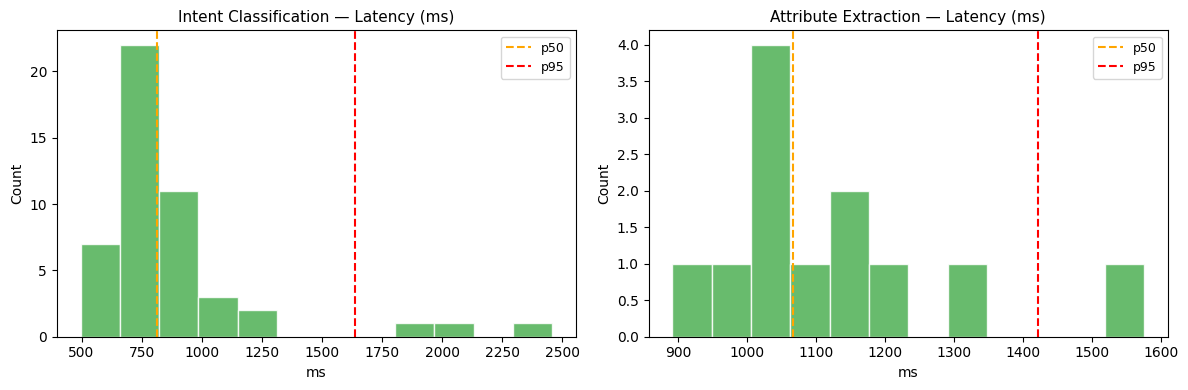

In [43]:
# ── Per-call latency distribution ────────────────────────────────────────────
intent_lats     = [r.latency_ms for r in intent_results]
extraction_lats = [r.latency_ms for r in extraction_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, lats, title in zip(
    axes,
    [intent_lats, extraction_lats],
    ["Intent Classification — Latency (ms)", "Attribute Extraction — Latency (ms)"]
):
    ax.hist(lats, bins=12, color="#4eb054", edgecolor="white", alpha=0.85)
    ax.axvline(pd.Series(lats).median(), color="orange", linestyle="--", linewidth=1.5, label="p50")
    ax.axvline(pd.Series(lats).quantile(0.95), color="red", linestyle="--", linewidth=1.5, label="p95")
    ax.set_xlabel("ms"); ax.set_ylabel("Count")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


#### Summary & Actionable Insights

In [44]:
ia   = intent_summary["accuracy"]
iw   = intent_summary["weighted_avg"]["f1"]
er   = extraction_summary["perfect_rate"]
eh   = extraction_summary["total_hallucinations"]

grade = lambda v, t1, t2: "A" if v >= t1 else "B" if v >= t2 else "C"
gi = grade(ia, 0.92, 0.80)
ge = grade(er, 0.85, 0.70)

print("=" * 56)
print("  SUMMARY")
print("=" * 56)
print(f"  Intent Classification")
print(f"    Accuracy         {ia:.1%}   Grade: {gi}")
print(f"    Weighted F1      {iw:.1%}")
print()
print(f"  Attribute Extraction")
print(f"    Perfect cases    {er:.1%}   Grade: {ge}")
print(f"    Hallucinations   {eh}")
print("=" * 56)

print("\n  Actionable Insights:")
worst_classes = sorted(intent_summary["per_class"].items(), key=lambda x: x[1]["f1"])[:2]
for cls, m in worst_classes:
    if m["support"] > 0 and m["f1"] < 0.85:
        print(f"  ⚠️  Intent '{cls}' has low F1={m['f1']:.2f} — add examples to INTENT_PROMPT")

if eh > 0:
    print(f"  ⚠️  {eh} hallucination(s) in extraction — strengthen null rules in EXTRACTION_PROMPT")

if intent_summary["by_difficulty"].get("hard", 1.0) < 0.7:
    print("  ⚠️  Hard cases underperform — add few-shot examples for edge cases")

if ia >= 0.92 and er >= 0.85:
    print("  ✅ Both prompts performing well. Consider running on a larger blind test set.")

  SUMMARY
  Intent Classification
    Accuracy         97.9%   Grade: A
    Weighted F1      97.9%

  Attribute Extraction
    Perfect cases    83.3%   Grade: B
    Hallucinations   2

  Actionable Insights:
  ⚠️  2 hallucination(s) in extraction — strengthen null rules in EXTRACTION_PROMPT


#### Save Full Results to JSON

In [45]:
import json, pathlib

out = {"intent": intent_summary, "extraction": extraction_summary}
path = pathlib.Path("output/llm_eval_results.json")
with open(path, "w", encoding="utf-8") as f:
    json.dump(out, f, indent=2, ensure_ascii=False, default=str)

print(f"✅ Results saved to {path.resolve()}")


✅ Results saved to /home/carlosbravo/Documents/MasOrange/Code/BN_TV_Recommender/main/output/llm_eval_results.json
